# Validation Study: Temporal & Spatial Splits

The main experiment uses a **random train/test split** (matching Karim et al. 2025).  
This notebook investigates how performance changes under two stricter validation strategies:

1. **Temporal split** - train on measurements before a cutoff date, test on later ones.  
   Eliminates temporal leakage confirmed by ACF (DW≈0.00 at densest stations).

2. **Spatial split** - hold out entire stations as test set (station-level leave-out).  
   Uses Geonames-geocoded lat/lon for 1,533 Ireland stations to compute Moran's I.  
   Eliminates leakage from ICC=0.310 station-level repeatability.

Both use the **Ireland subset** (the only dataset with dense enough time series and geocodable station names).

In [2]:
import os, sys
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sys.path.insert(0, os.path.abspath('..'))
from config import OUTPUT_DIR, FEATURES, TARGET, RANDOM_SEED

# Validation always uses full Ireland data regardless of config MODE
_root        = os.path.abspath('..')
IRELAND_PATH = os.path.join(_root, 'data', 'Dataset', 'Country-Wise Data', 'Ireland_dataset.csv')
_bulk        = os.path.join(_root, 'output', 'ireland_stations_geocode_bulk.csv')
_old         = os.path.join(_root, 'output', 'ireland_stations_geocode_coded.csv')
GEO_PATH     = _bulk if os.path.exists(_bulk) else _old

CUTOFF         = '2018-01-01'   # temporal split cutoff
N_HOLDOUT_FRAC = 0.15           # fraction of geocoded stations held out for spatial test

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f'Ireland data    : {IRELAND_PATH}')
print(f'Geocode file    : {GEO_PATH}')
print(f'Temporal cutoff : {CUTOFF}')
print(f'Holdout fraction: {N_HOLDOUT_FRAC*100:.0f}% of geocoded stations')

In [3]:
# ── Load & clean data ─────────────────────────────────────────────────────────
df = pd.read_csv(IRELAND_PATH)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
# Sort per station (earliest→latest within each station, then next station)
df = df.sort_values(['Area', 'Date']).reset_index(drop=True)
df = df[FEATURES + [TARGET, 'Area', 'Date']].dropna()

# IQR outlier removal (matching main pipeline)
mask = pd.Series(True, index=df.index)
for col in FEATURES:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask &= (df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)
df = df[mask].reset_index(drop=True)

print(f'After IQR removal: {len(df):,} rows, {df["Area"].nunique()} stations')
print(f'Date range: {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Sorted by: (Area, Date) — consecutive rows within a station are chronological')
# Show example
example = df[df['Area'] == df['Area'].iloc[0]][['Area','Date',TARGET]].head(4)
print(f'Example station ordering:')
print(example.to_string(index=False))

After IQR removal: 60,298 rows, 3394 stations
Date range: 2001-11-06 → 2023-12-13
Sorted by: (Area, Date) — consecutive rows within a station are chronological
Example station ordering:
                                        Area       Date  CCME_Values
Ballyteigue-Bannow, BRIDGETOWN (WEXFORD)_021 2012-05-24        100.0


In [4]:
# ── Shared helpers ────────────────────────────────────────────────────────────
SEQ_LEN = 4   # timesteps per LSTM sequence (tunable)

def make_sequences(X, y, areas, seq_len=SEQ_LEN):
    """Build overlapping sequences within each station.
    Each sequence is seq_len consecutive measurements from the same station.
    Returns X_seq (n, seq_len, n_feat), y_seq (n,).
    """
    Xs, ys = [], []
    for area in np.unique(areas):
        idx = np.where(areas == area)[0]
        if len(idx) < seq_len:
            continue
        for start in range(len(idx) - seq_len + 1):
            sl = idx[start:start + seq_len]
            Xs.append(X[sl])          # (seq_len, n_feat)
            ys.append(y[sl[-1]])      # predict last step
    if not Xs:
        return np.empty((0, seq_len, X.shape[1])), np.empty(0)
    return np.array(Xs), np.array(ys)

def scale_split(X_tr, y_tr, X_te):
    sc_x = StandardScaler().fit(X_tr)
    sc_y = MinMaxScaler().fit(y_tr.reshape(-1,1))
    return sc_x.transform(X_tr), sc_x.transform(X_te), sc_y, sc_x

def eval_metrics(y_true, y_pred, label=''):
    if len(y_true) == 0:
        print(f'{label:30s}  no samples')
        return {'r2': None, 'rmse': None, 'mae': None}
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f'{label:30s}  R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}')
    return {'r2': r2, 'rmse': rmse, 'mae': mae}

def build_ann(n_feat):
    tf.random.set_seed(RANDOM_SEED)
    m = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_feat,)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1),
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    return m

def build_lstm(seq_len, n_feat):
    tf.random.set_seed(RANDOM_SEED)
    m = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(seq_len, n_feat)),
        tf.keras.layers.LSTM(50),
        tf.keras.layers.Dense(1),
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    return m

CBS = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0),
]
print(f'Helpers ready. SEQ_LEN={SEQ_LEN}')

Helpers ready. SEQ_LEN=4


---
## Part 1 — Temporal Validation

Train on all measurements **before** the cutoff date, test on measurements **from** the cutoff onwards.  
This is the strictest form of temporal validation — no future data leaks into training.

In [5]:
# ── Temporal split ────────────────────────────────────────────────────────────
cutoff = pd.Timestamp(CUTOFF)
train_t = df[df['Date'] < cutoff].copy()
test_t  = df[df['Date'] >= cutoff].copy()

print(f'Train: {len(train_t):,} rows ({train_t["Date"].min().date()} → {train_t["Date"].max().date()})')
print(f'Test : {len(test_t):,} rows  ({test_t["Date"].min().date()} → {test_t["Date"].max().date()})')

# Last 15% of training as validation (preserve temporal order within stations)
val_cut = int(len(train_t) * 0.85)
val_t   = train_t.iloc[val_cut:].copy()
train_t = train_t.iloc[:val_cut].copy()

X_tr, y_tr = train_t[FEATURES].values, train_t[TARGET].values
X_v,  y_v  = val_t[FEATURES].values,   val_t[TARGET].values
X_te, y_te = test_t[FEATURES].values,  test_t[TARGET].values

sc_x_t = StandardScaler().fit(X_tr)
sc_y_t = MinMaxScaler().fit(y_tr.reshape(-1,1))
X_tr_s = sc_x_t.transform(X_tr)
X_v_s  = sc_x_t.transform(X_v)
X_te_s = sc_x_t.transform(X_te)
y_tr_s = sc_y_t.transform(y_tr.reshape(-1,1)).flatten()
y_v_s  = sc_y_t.transform(y_v.reshape(-1,1)).flatten()

print(f'Val  : {len(val_t):,} rows')

Train: 43,803 rows (2001-11-06 → 2017-12-31)
Test : 16,495 rows  (2018-01-04 → 2023-12-13)
Val  : 6,571 rows


In [6]:
# ── Train RF (temporal) ───────────────────────────────────────────────────────
rf_t = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
rf_t.fit(X_tr_s, y_tr)
y_pred_rf_t = rf_t.predict(X_te_s)
res_rf_t = eval_metrics(y_te, y_pred_rf_t, 'RF (temporal split)')

RF (temporal split)             R²=0.9998  RMSE=0.0085  MAE=0.0001


In [7]:
# ── Train ANN (temporal) ──────────────────────────────────────────────────────
ann_t = build_ann(len(FEATURES))
ann_t.fit(X_tr_s, y_tr_s, validation_data=(X_v_s, y_v_s),
          epochs=100, batch_size=256, callbacks=CBS, verbose=0)
y_pred_ann_t = sc_y_t.inverse_transform(
    ann_t.predict(X_te_s, verbose=0)).flatten()
res_ann_t = eval_metrics(y_te, y_pred_ann_t, 'ANN (temporal split)')

ANN (temporal split)            R²=0.9638  RMSE=0.1208  MAE=0.0123


In [8]:
# ── Train LSTM (temporal) — proper per-station sequences ─────────────────────
areas_tr = train_t['Area'].values
areas_v  = val_t['Area'].values
areas_te = test_t['Area'].values

X_seq_tr, y_seq_tr = make_sequences(X_tr_s, y_tr_s,  areas_tr)
X_seq_v,  y_seq_v  = make_sequences(X_v_s,  y_v_s,   areas_v)
X_seq_te, y_seq_te_s = make_sequences(X_te_s, sc_y_t.transform(y_te.reshape(-1,1)).flatten(), areas_te)
# also build unsealed y for eval
_, y_seq_te_raw = make_sequences(X_te_s, y_te, areas_te)

print(f'LSTM train sequences: {len(X_seq_tr)}, val: {len(X_seq_v)}, test: {len(X_seq_te)}')

lstm_t = build_lstm(SEQ_LEN, len(FEATURES))
lstm_t.fit(X_seq_tr, y_seq_tr, validation_data=(X_seq_v, y_seq_v),
           epochs=100, batch_size=256, callbacks=CBS, verbose=0)

y_pred_lstm_t = sc_y_t.inverse_transform(
    lstm_t.predict(X_seq_te, verbose=0)).flatten()
res_lstm_t = eval_metrics(y_seq_te_raw, y_pred_lstm_t, 'LSTM (temporal split)')

LSTM train sequences: 31770, val: 5636, test: 11931
LSTM (temporal split)           R²=-0.7682  RMSE=0.8433  MAE=0.4832


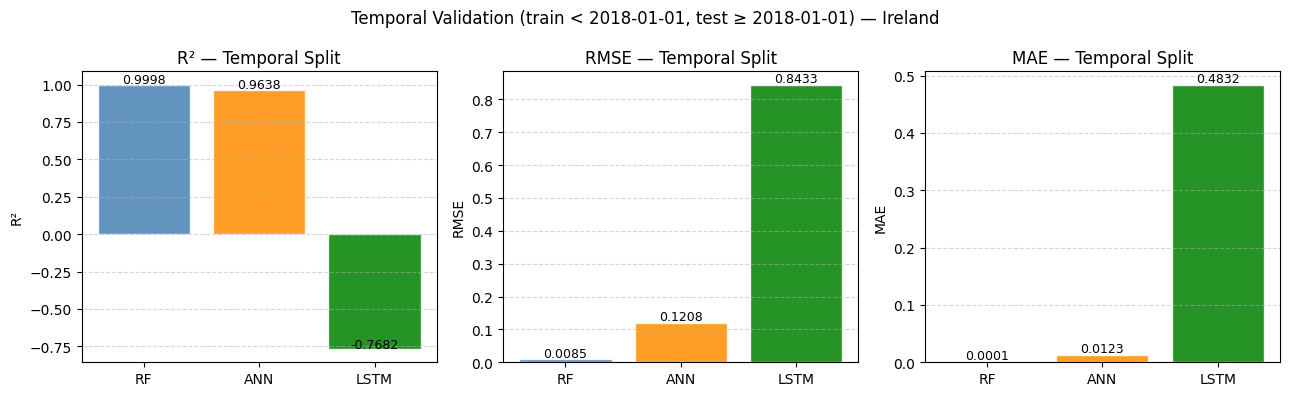

Saved to output/validation_temporal.png


In [9]:
# ── Temporal results plot ─────────────────────────────────────────────────────
models_t   = ['RF', 'ANN', 'LSTM']
results_t  = [res_rf_t, res_ann_t, res_lstm_t]
colors     = ['steelblue', 'darkorange', 'green']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric, ylabel in zip(axes, ['r2','rmse','mae'], ['R²','RMSE','MAE']):
    vals = [r[metric] for r in results_t]
    bars = ax.bar(models_t, vals, color=colors, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(vals)*0.01,
                f'{v:.4f}', ha='center', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} — Temporal Split')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle(f'Temporal Validation (train < {CUTOFF}, test ≥ {CUTOFF}) — Ireland', fontsize=12)
plt.tight_layout()
plt.savefig(f'../output/validation_temporal.png', dpi=150)
plt.show()
print('Saved to output/validation_temporal.png')

---
## Part 2 — Spatial Validation

Hold out **entire stations** as the test set — the model never sees any measurement from those stations during training.  
Stations are selected spatially: the N_HOLDOUT stations furthest from the training station centroid are withheld,  
ensuring the test set covers geographically distinct areas.

We also compute **Moran's I** on the geocoded stations to quantify spatial autocorrelation in mean WQI.

In [10]:
# ── Load geocoded stations & merge ────────────────────────────────────────────
geo = pd.read_csv(GEO_PATH)
geo = geo[geo['latitude'].notna()][['Area', 'latitude', 'longitude']].drop_duplicates('Area')
print(f'Geocoded stations: {len(geo)}')

df_geo = df.merge(geo, on='Area', how='inner')
print(f'Rows with coordinates: {len(df_geo):,} / {len(df):,}')
print(f'Unique geocoded stations: {df_geo["Area"].nunique()}')

Geocoded stations: 1659
Rows with coordinates: 45,393 / 60,298
Unique geocoded stations: 1533


In [ ]:
# ── Moran's I on mean WQI per station ────────────────────────────────────────
from scipy.spatial.distance import cdist

station_stats = df_geo.groupby('Area').agg(
    lat=('latitude','first'),
    lon=('longitude','first'),
    mean_wqi=(TARGET,'mean'),
    n=('Area','count')
).reset_index()

coords = station_stats[['lat','lon']].values
y_wqi  = station_stats['mean_wqi'].values

# Add tiny jitter to duplicate coordinates to avoid division by zero
rng_jitter = np.random.default_rng(0)
coords = coords + rng_jitter.uniform(-1e-5, 1e-5, coords.shape)

# Inverse distance weights (row-normalised)
dist = cdist(coords, coords, metric='euclidean')
np.fill_diagonal(dist, np.inf)
W = 1.0 / dist
W /= W.sum(axis=1, keepdims=True)

n   = len(y_wqi)
y_  = y_wqi - y_wqi.mean()
I   = (n / W.sum()) * (y_ @ W @ y_) / (y_ @ y_)

# Permutation test for p-value
rng = np.random.default_rng(RANDOM_SEED)
null = []
for _ in range(999):
    yp = rng.permutation(y_wqi)
    yp_ = yp - yp.mean()
    null.append((n / W.sum()) * (yp_ @ W @ yp_) / (yp_ @ yp_))
p_val = (np.sum(np.array(null) >= I) + 1) / 1000

print(f"Moran's I = {I:.4f}  (p={p_val:.3f}, permutation test, 999 iterations)")
if I > 0.3 and p_val < 0.05:
    print('-> Strong positive spatial autocorrelation: nearby stations share similar WQI levels')
elif I > 0.1 and p_val < 0.05:
    print('-> Moderate positive spatial autocorrelation')
elif p_val >= 0.05:
    print('-> Not statistically significant spatial autocorrelation')
else:
    print('-> Weak or negative spatial autocorrelation')


Moran's I = 0.6597  (p=0.001, permutation test, 999 iterations)
→ Strong positive spatial autocorrelation: nearby stations share similar WQI levels


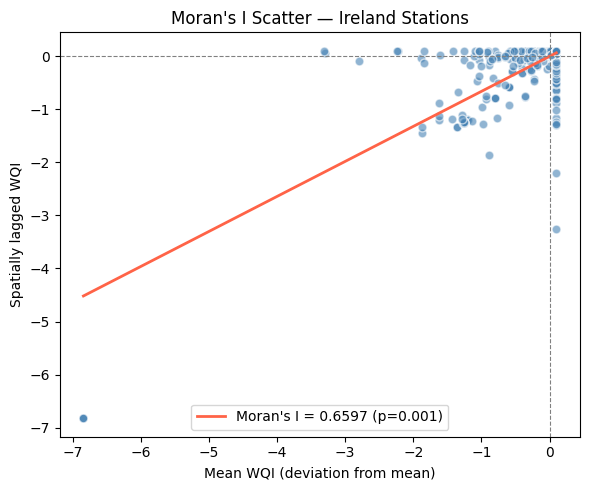

Saved to output/validation_morans_i.png


In [12]:
# ── Moran scatter plot ────────────────────────────────────────────────────────
Wy = W @ y_

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_, Wy, alpha=0.6, color='steelblue', edgecolors='white', s=40)
m, b = np.polyfit(y_, Wy, 1)
x_line = np.linspace(y_.min(), y_.max(), 100)
ax.plot(x_line, m*x_line+b, color='tomato', lw=2, label=f"Moran's I = {I:.4f} (p={p_val:.3f})")
ax.axhline(0, color='grey', lw=0.8, linestyle='--')
ax.axvline(0, color='grey', lw=0.8, linestyle='--')
ax.set_xlabel('Mean WQI (deviation from mean)')
ax.set_ylabel('Spatially lagged WQI')
ax.set_title("Moran's I Scatter — Ireland Stations")
ax.legend()
plt.tight_layout()
plt.savefig('../output/validation_morans_i.png', dpi=150)
plt.show()
print('Saved to output/validation_morans_i.png')

In [13]:
# ── Select holdout stations (spatially peripheral) ────────────────────────────
centroid = coords.mean(axis=0)
dist_to_centroid = np.linalg.norm(coords - centroid, axis=1)
station_stats['dist_to_centroid'] = dist_to_centroid
station_stats = station_stats.sort_values('dist_to_centroid', ascending=False)

n_holdout = max(5, int(len(station_stats) * N_HOLDOUT_FRAC))
holdout_stations = station_stats.head(n_holdout)['Area'].tolist()
train_stations   = station_stats.iloc[n_holdout:]['Area'].tolist()
print(f'Holding out {n_holdout} / {len(station_stats)} geocoded stations ({N_HOLDOUT_FRAC*100:.0f}%)')

train_s = df_geo[df_geo['Area'].isin(train_stations)]
test_s  = df_geo[df_geo['Area'].isin(holdout_stations)]

print(f'Train: {len(train_s):,} rows ({len(train_stations)} stations)')
print(f'Test : {len(test_s):,} rows  ({len(holdout_stations)} stations — spatially peripheral)')
print('Holdout stations:', holdout_stations[:5], '...')

Holding out 229 / 1533 geocoded stations (15%)
Train: 36,380 rows (1304 stations)
Test : 9,013 rows  (229 stations — spatially peripheral)
Holdout stations: ['Upper Shannon (F), INNY_050', 'Upper Shannon (F), INNY_020', 'Upper Shannon (F), INNY_010', 'Upper Shannon (F), INNY_090', 'Upper Shannon (F), INNY_060'] ...


In [14]:
# ── Scale & train all 3 models (spatial split) ────────────────────────────────
X_tr = train_s[FEATURES].values
y_tr = train_s[TARGET].values
X_te = test_s[FEATURES].values
y_te = test_s[TARGET].values
areas_tr_all = train_s['Area'].values
areas_te_s   = test_s['Area'].values

# 15% of training as validation (preserve station grouping)
val_idx = int(len(X_tr) * 0.85)
X_v,  y_v  = X_tr[val_idx:], y_tr[val_idx:]
X_tr, y_tr = X_tr[:val_idx], y_tr[:val_idx]
areas_tr_s2 = areas_tr_all[:val_idx]
areas_v_s2  = areas_tr_all[val_idx:]

sc_x = StandardScaler().fit(X_tr)
X_tr_s, X_v_s, X_te_s = sc_x.transform(X_tr), sc_x.transform(X_v), sc_x.transform(X_te)
sc_y = MinMaxScaler().fit(y_tr.reshape(-1,1))
y_tr_s = sc_y.transform(y_tr.reshape(-1,1)).flatten()
y_v_s  = sc_y.transform(y_v.reshape(-1,1)).flatten()

# RF
rf_s = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
rf_s.fit(X_tr_s, y_tr)
res_rf_s = eval_metrics(y_te, rf_s.predict(X_te_s), 'RF (spatial split)')

# ANN
ann_s = build_ann(len(FEATURES))
ann_s.fit(X_tr_s, y_tr_s, validation_data=(X_v_s, y_v_s),
          epochs=100, batch_size=256, callbacks=CBS, verbose=0)
y_pred_ann_s = sc_y.inverse_transform(ann_s.predict(X_te_s, verbose=0)).flatten()
res_ann_s = eval_metrics(y_te, y_pred_ann_s, 'ANN (spatial split)')

# LSTM — per-station sequences
X_seq_tr_s, y_seq_tr_s = make_sequences(X_tr_s, y_tr_s, areas_tr_s2)
X_seq_v_s,  y_seq_v_s  = make_sequences(X_v_s,  y_v_s,  areas_v_s2)
y_te_scaled = sc_y.transform(y_te.reshape(-1,1)).flatten()
X_seq_te_s, _           = make_sequences(X_te_s, y_te_scaled, areas_te_s)
_, y_seq_te_s_raw       = make_sequences(X_te_s, y_te,        areas_te_s)

print(f'LSTM spatial sequences — train: {len(X_seq_tr_s)}, val: {len(X_seq_v_s)}, test: {len(X_seq_te_s)}')
if len(X_seq_tr_s) > 0 and len(X_seq_te_s) > 0:
    lstm_s = build_lstm(SEQ_LEN, len(FEATURES))
    lstm_s.fit(X_seq_tr_s, y_seq_tr_s, validation_data=(X_seq_v_s, y_seq_v_s),
               epochs=100, batch_size=256, callbacks=CBS, verbose=0)
    y_pred_lstm_s = sc_y.inverse_transform(
        lstm_s.predict(X_seq_te_s, verbose=0)).flatten()
    res_lstm_s = eval_metrics(y_seq_te_s_raw, y_pred_lstm_s, 'LSTM (spatial split)')
else:
    print('Not enough sequences for LSTM')
    res_lstm_s = {'r2': None, 'rmse': None, 'mae': None}

RF (spatial split)              R²=1.0000  RMSE=0.0002  MAE=0.0000
ANN (spatial split)             R²=-25.6864  RMSE=2.4644  MAE=2.3069
LSTM spatial sequences — train: 27794, val: 4891, test: 8372
LSTM (spatial split)            R²=-2.2826  RMSE=0.8660  MAE=0.6135


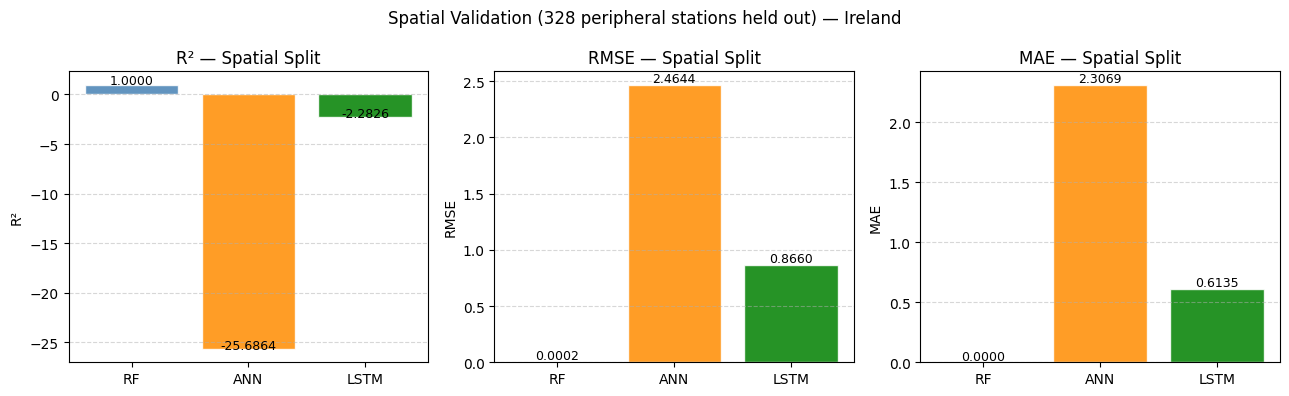

Saved to output/validation_spatial.png


In [15]:
# ── Spatial results plot ──────────────────────────────────────────────────────
models_s  = ['RF', 'ANN', 'LSTM']
results_s = [res_rf_s, res_ann_s, res_lstm_s]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric, ylabel in zip(axes, ['r2','rmse','mae'], ['R²','RMSE','MAE']):
    vals = [r[metric] for r in results_s]
    bars = ax.bar(models_s, vals, color=colors, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(vals)*0.01,
                f'{v:.4f}', ha='center', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} — Spatial Split')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle(f'Spatial Validation ({N_HOLDOUT} peripheral stations held out) — Ireland', fontsize=12)
plt.tight_layout()
plt.savefig('../output/validation_spatial.png', dpi=150)
plt.show()
print('Saved to output/validation_spatial.png')

In [16]:
# ── Summary comparison: random vs temporal vs spatial ─────────────────────────
from sklearn.model_selection import train_test_split as tts

# Use index-based split so we can track Area labels
idx_all = np.arange(len(df))
idx_tr, idx_te = tts(idx_all, test_size=0.15, random_state=RANDOM_SEED)
idx_tr, idx_v  = tts(idx_tr,  test_size=0.15, random_state=RANDOM_SEED)

X_r_tr, y_r_tr = df.iloc[idx_tr][FEATURES].values, df.iloc[idx_tr][TARGET].values
X_r_v,  y_r_v  = df.iloc[idx_v][FEATURES].values,  df.iloc[idx_v][TARGET].values
X_r_te, y_r_te = df.iloc[idx_te][FEATURES].values,  df.iloc[idx_te][TARGET].values
areas_r_tr = df.iloc[idx_tr]['Area'].values
areas_r_v  = df.iloc[idx_v]['Area'].values
areas_r_te = df.iloc[idx_te]['Area'].values

sc_xr = StandardScaler().fit(X_r_tr)
sc_yr = MinMaxScaler().fit(y_r_tr.reshape(-1,1))
X_r_tr_s = sc_xr.transform(X_r_tr)
X_r_v_s  = sc_xr.transform(X_r_v)
X_r_te_s = sc_xr.transform(X_r_te)
y_r_tr_s = sc_yr.transform(y_r_tr.reshape(-1,1)).flatten()
y_r_v_s  = sc_yr.transform(y_r_v.reshape(-1,1)).flatten()

# RF
rf_r = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
rf_r.fit(X_r_tr_s, y_r_tr)
res_rf_r = eval_metrics(y_r_te, rf_r.predict(X_r_te_s), 'RF (random split)')

# ANN
ann_r = build_ann(len(FEATURES))
ann_r.fit(X_r_tr_s, y_r_tr_s, validation_data=(X_r_v_s, y_r_v_s),
          epochs=100, batch_size=256, callbacks=CBS, verbose=0)
res_ann_r = eval_metrics(y_r_te,
    sc_yr.inverse_transform(ann_r.predict(X_r_te_s, verbose=0)).flatten(), 'ANN (random split)')

# LSTM — per-station sequences
X_seq_r_tr, y_seq_r_tr = make_sequences(X_r_tr_s, y_r_tr_s, areas_r_tr)
X_seq_r_v,  y_seq_r_v  = make_sequences(X_r_v_s,  y_r_v_s,  areas_r_v)
y_r_te_s = sc_yr.transform(y_r_te.reshape(-1,1)).flatten()
X_seq_r_te, _          = make_sequences(X_r_te_s, y_r_te_s,  areas_r_te)
_, y_seq_r_te_raw      = make_sequences(X_r_te_s, y_r_te,    areas_r_te)

print(f'LSTM random sequences — train: {len(X_seq_r_tr)}, val: {len(X_seq_r_v)}, test: {len(X_seq_r_te)}')
lstm_r = build_lstm(SEQ_LEN, len(FEATURES))
lstm_r.fit(X_seq_r_tr, y_seq_r_tr, validation_data=(X_seq_r_v, y_seq_r_v),
           epochs=100, batch_size=256, callbacks=CBS, verbose=0)
res_lstm_r = eval_metrics(y_seq_r_te_raw,
    sc_yr.inverse_transform(lstm_r.predict(X_seq_r_te, verbose=0)).flatten(),
    'LSTM (random split)')

RF (random split)               R²=1.0000  RMSE=0.0001  MAE=0.0000
ANN (random split)              R²=-10.1642  RMSE=2.3946  MAE=2.3198
LSTM random sequences — train: 36595, val: 3831, test: 4925
LSTM (random split)             R²=-0.5087  RMSE=0.8522  MAE=0.4680


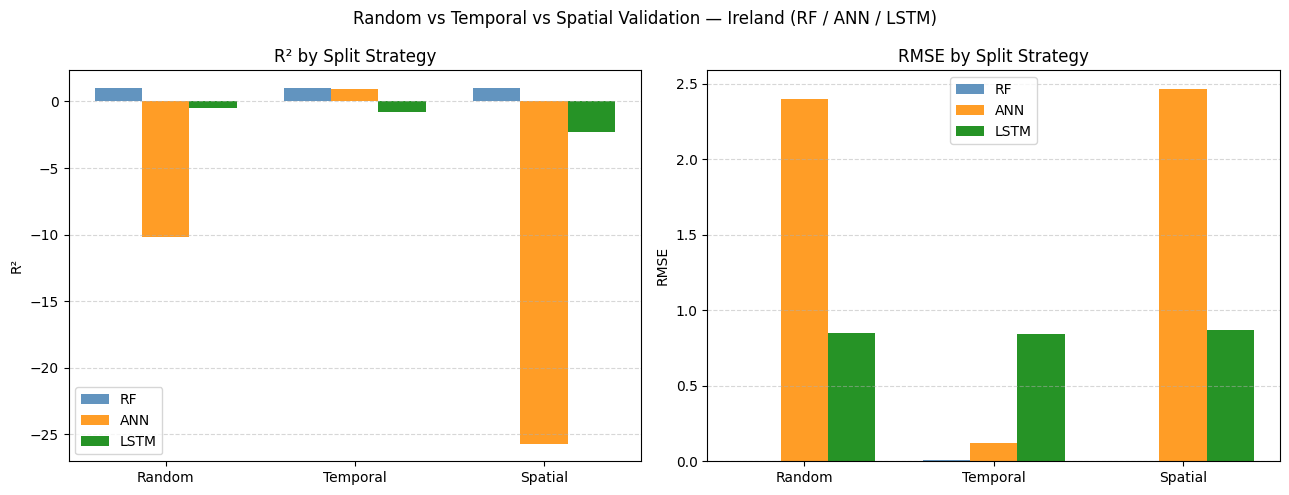

Saved to output/validation_comparison.png

== SUMMARY ==
          Random R²  Temporal R²   Spatial R²
RF           1.0000       0.9998       1.0000
ANN        -10.1642       0.9638     -25.6864
LSTM        -0.5087      -0.7682      -2.2826


In [17]:
# ── Final 3-way comparison plot ───────────────────────────────────────────────
splits    = ['Random', 'Temporal', 'Spatial']
rf_r2s    = [res_rf_r['r2'],   res_rf_t['r2'],   res_rf_s['r2']]
ann_r2s   = [res_ann_r['r2'],  res_ann_t['r2'],  res_ann_s['r2']]
lstm_r2s  = [res_lstm_r['r2'], res_lstm_t['r2'], res_lstm_s['r2']]
rf_rmse   = [res_rf_r['rmse'],   res_rf_t['rmse'],   res_rf_s['rmse']]
ann_rmse  = [res_ann_r['rmse'],  res_ann_t['rmse'],  res_ann_s['rmse']]
lstm_rmse = [res_lstm_r['rmse'], res_lstm_t['rmse'], res_lstm_s['rmse']]

x = np.arange(3)
w = 0.25
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, rf_v, ann_v, lstm_v, ylabel in [
    (ax1, rf_r2s,  ann_r2s,  lstm_r2s,  'R²'),
    (ax2, rf_rmse, ann_rmse, lstm_rmse, 'RMSE'),
]:
    ax.bar(x - w, rf_v,   w, label='RF',   color='steelblue',  alpha=0.85)
    ax.bar(x,     ann_v,  w, label='ANN',  color='darkorange', alpha=0.85)
    ax.bar(x + w, lstm_v, w, label='LSTM', color='green',      alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(splits)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} by Split Strategy')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Random vs Temporal vs Spatial Validation — Ireland (RF / ANN / LSTM)', fontsize=12)
plt.tight_layout()
plt.savefig('../output/validation_comparison.png', dpi=150)
plt.show()
print('Saved to output/validation_comparison.png')
print()
print('== SUMMARY ==')
print(f'{"":<6} {"Random R²":>12} {"Temporal R²":>12} {"Spatial R²":>12}')
for name, vals in [("RF",rf_r2s),("ANN",ann_r2s),("LSTM",lstm_r2s)]:
    print(f'{name:<6} {vals[0]:>12.4f} {vals[1]:>12.4f} {vals[2]:>12.4f}')